### 1. Ví dụ và giới thiệu
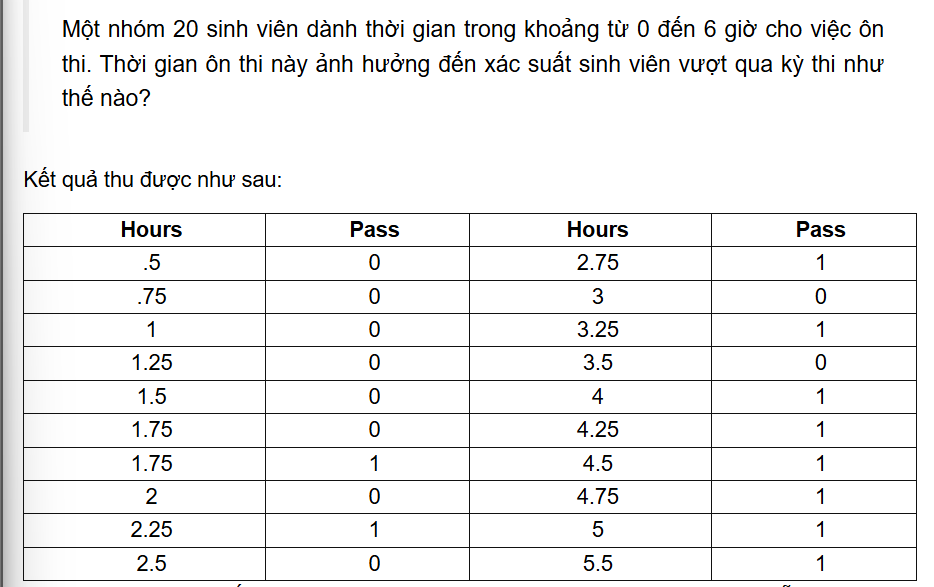
- Trong bài toán này ta nhận thấy rằng có những điểm outlier như nào học 3.5h thì trượt còn học 1.75 giờ thì lại đỗ khi đó ta không thế nào dùng hồi quy tuyến tính để giải bài này được.

### 2. Mô hình Logistic Regression

- Các mô hình của bài toán hồi quy:
$$ y = f(\mathbf{w^{T}} \mathbf{x})$$
- Trong đó:
    - $\mathbf{w^{T}} \mathbf{x}$ là phần tuyến tính
    - $f(.)$: hàm kích hoạt( trong hồi quy tuyến tính thì là $f(x) = x$)

- Đầu ra dự đoán của Regression:
$$ f(\mathbf x) = \mathbf{w}^{T} \mathbf{x}$$
- Đầu ra của PLA( chưa học)
- Đầu ra dự đoán của logistic regression:
$$ f(\mathbf x) =\theta{(\mathbf{w}^{T} \mathbf{x})}$$
    
Trong đó θ đươc gọi là logistic funtion.

- Biểu diễn minh họa ví dụ trên trong hình dưới đây:

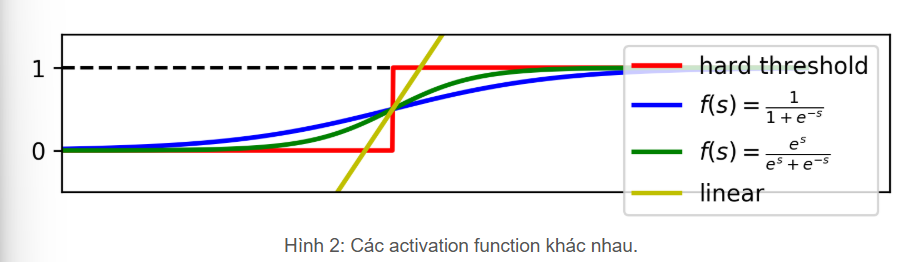

Ta nhận rằng: đường màu vàng dùng để biểu diễn Linear Regression do đường này không bị chặn nên không phù hợp với bài toán. Có một trick có thể giới hạn được 2 đầu: chúng ta cho những điểm nhỏ hơn 0 là vào lớp 0 còn những điểm lớn hơn 1 là được phân vào lớp 1. Sau đó lấy đường thẳng y = 0.5 để xác định những điểm đỗ hay trượt. Nhưng mà khi mà có thêm điểm outliers VD: Điểm khi x = 20 thì chắc chắn là sẽ được xếp vào lớp 1. Khi áp dụng LinearR ta có hình dưới đây.
    
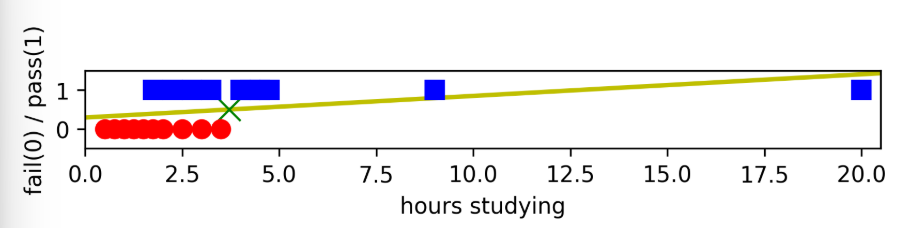

Nhận thấy rằng những sinh viên trượt thì vẫn sẽ trượt nhưng có những bạn từ đỗ chuyển sang trượt (lấy điểm X màu xanh trong ảnh để phân lớp) ⇒ ta thấy rằng điểm outlier này làm cho mô hình không tốt.
    
- Đường màu xanh và lục hợp với bài toán hơn:
    - Là hàm số liên tục nhận giá trị thực bị chặn trong khoảng (0, 1)
    - Nếu coi điểm y = 0,5 là điểm phân loại thì các điểm càng xa điểm này về phía bên trái có giá trị = 0 và tương tự như điểm bên x = 1
    - Mượt có đạo hàm mọi nơi

### 3. Sigmoid function
- Hàm sigmoid có dạng:
$$ f(s) = \frac{1}{1 + e^{-s}} \triangleq \sigma{(s)}$$
- được sử dụng nhiều vì nó bị chặn trong (0, 1):
$$
\lim_{s \to -\infty} \sigma(s) = 0,\quad 
\lim_{s \to +\infty} \sigma(s) = 1
$$

- Đặc biệt hơn nữa:
$$ \sigma'(s) = \frac{e^{-s}}{(1 + e^{-s})^{2}} \\
= \frac{1}{1 + e^{-s}} \frac{e^{-s}}{1 + e^{-s}} \\
= \sigma(s)(1 - \sigma(s))$$
- Ngoài ra, hàm $\tanh$ cũng hay được sử dụng:
$$ \tanh{(s)} = \frac{e^{s} - e^{-s}}{e^{s} + e^{-s}}$$
- Hàm số này nhận giá trị trong khoảng (-1, 1) nhưng có thể dễ dàng đưa nó về khoảng (0, 1).
$$\tanh{(s)} = 2\sigma(2s) - 1$$



### 4. Hàm mất mát và phương pháp tối ưu
- Với mô hình dữ liệu như trên ta có thể giả sử rằng xác suất để một điểm dữ liệu $\mathbf x$ rơi và class 1 là $f(\mathbf{w}^{T}\mathbf{x}) $ và rơi vào class 0 là $1 - f(\mathbf{w}^{T}\mathbf{x})$
$$ P(y_i = 1 | \mathbf{x_i}; \mathbf{w}) = f(\mathbf{w}^{T}\mathbf{x}) \quad (1)\\
P(y_i = 0 | \mathbf{x_i}; \mathbf{w}) = 1 - f(\mathbf{w}^{T}\mathbf{x}) \quad (2)$$
- Từ phương trình (1) và (2) ta có thể đặt gọn lại thành:
    - Đặt $z_i = f(\mathbf{w}^{T}\mathbf{x})$ ta có:
$$ P(y_i|\mathbf{x}_i; \mathbf{w}) = z_i^{y_i}(1 - z_i)^{1 - y_i}$$

- Ta xét toàn bộ tập training với $\mathbf{X} = [\mathbf{x_1, x_2, ..., x_N}] \in \mathbf{R}^{dxN}$ và $\mathbf{y} = [y_1, y_2, ..., y_N]$ chúng ta cần tìm $\mathbf{w}$ để biểu thức sau đây max:
$$\mathbf{w} = \arg\max_{\mathbf{w}}P(\mathbf{y}|\mathbf{X}; \mathbf{w})
$$
- Bài toán tìm tham số để mô hình gần với dữ liệu nhất trên đây có tên gọi chung là bài toàn **maximum likelihood estimation** với hàm số phía sau argmax được gọi là **likelihood function**
- Giả sử rằng các điểm được sinh ra một cách ngẫu nhiên ta có:
$$P(\mathbf{y}|\mathbf{X}; \mathbf{w}) = \prod_{i=1}^{N} P(y_i|\mathbf{x_i}; \mathbf{w}) $$
$$=
\prod_{i = 1}^{N}z_i^{y_i}(1 - z_i)^{1 - y_i}$$


